DATASET:
Dataset link - https://www.kaggle.com/code/jayrdixit/student-mental-health/input

OBJECTIVE OF THE ANALYSIS:
To perform data visualization, aggregation, and data wrangling using Python.

In [1]:
#importing core libraries for data manipulation (pandas, numpy)
#and visualization (matplotlib, seaborn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_csv("students_mental_health_survey.csv")
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus
1,24,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus
2,19,Business,Female,3.74,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus
3,19,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus
4,18,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus


In [16]:
df.dtypes

Age                              int64
Course                             str
Gender                             str
CGPA                           float64
Stress_Level                     int64
Depression_Score                 int64
Anxiety_Score                    int64
Sleep_Quality                      str
Physical_Activity                  str
Diet_Quality                       str
Social_Support                     str
Relationship_Status                str
Substance_Use                      str
Counseling_Service_Use             str
Family_History                     str
Chronic_Illness                    str
Financial_Stress                 int64
Extracurricular_Involvement        str
Semester_Credit_Load             int64
Residence_Type                     str
dtype: object

In [17]:
# Check missing values
df.isnull().sum()

# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode (FIXED)
cat_cols = df.select_dtypes(include=['str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])   # removed inplace=True

In [18]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print(df.columns.tolist())

['Age', 'Course', 'Gender', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Financial_Stress', 'Extracurricular_Involvement', 'Semester_Credit_Load', 'Residence_Type']


In [19]:
# Example conversions (modify based on your dataset)
if 'age' in df.columns:
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

if 'sleep_hours' in df.columns:
    df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')

In [20]:
# Remove unrealistic values
if 'age' in df.columns:
    df = df[(df['age'] >= 16) & (df['age'] <= 35)]

if 'sleep_hours' in df.columns:
    df = df[(df['sleep_hours'] >= 3) & (df['sleep_hours'] <= 10)]

In [21]:
cols = ['sleep_hours', 'study_hours']

for col in cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

In [22]:
# Cap values instead of removing
Q1 = df['Stress_Level'].quantile(0.25)
Q3 = df['Stress_Level'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Stress_Level'] = df['Stress_Level'].clip(lower, upper)

In [23]:
print(df.isnull().sum().sum())

0


In [24]:
print(df.dtypes)

Age                              int64
Course                             str
Gender                             str
CGPA                           float64
Stress_Level                     int64
Depression_Score                 int64
Anxiety_Score                    int64
Sleep_Quality                      str
Physical_Activity                  str
Diet_Quality                       str
Social_Support                     str
Relationship_Status                str
Substance_Use                      str
Counseling_Service_Use             str
Family_History                     str
Chronic_Illness                    str
Financial_Stress                 int64
Extracurricular_Involvement        str
Semester_Credit_Load             int64
Residence_Type                     str
dtype: object


In [11]:
df.describe()

,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load
count,7022.000000,7022.000000,7022.000000,7022.000000,7022.000000,7022.000000,7022.000000
mean,23.003418,3.491285,2.427941,2.254486,2.300484,2.453005,22.010538
std,3.853978,0.287175,1.638408,1.625193,1.624305,1.708995,4.358380
min,18.000000,2.440000,0.000000,0.000000,0.000000,0.000000,15.000000
25%,20.000000,3.290000,1.000000,1.000000,1.000000,1.000000,18.000000
50%,22.000000,3.500000,2.000000,2.000000,2.000000,2.000000,22.000000
75%,25.000000,3.700000,4.000000,3.000000,4.000000,4.000000,26.000000
max,35.000000,4.000000,5.000000,5.000000,5.000000,5.000000,29.000000


In [25]:
df.shape

(7022, 20)

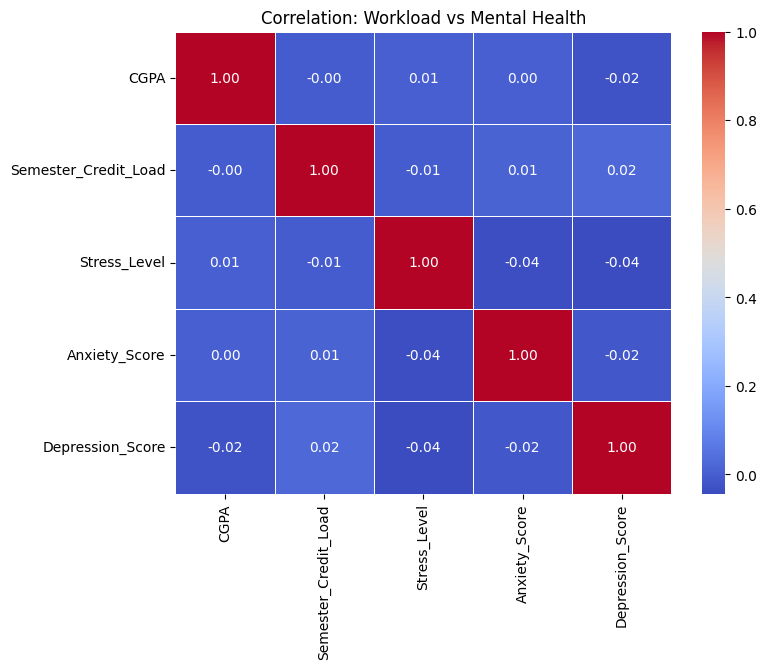

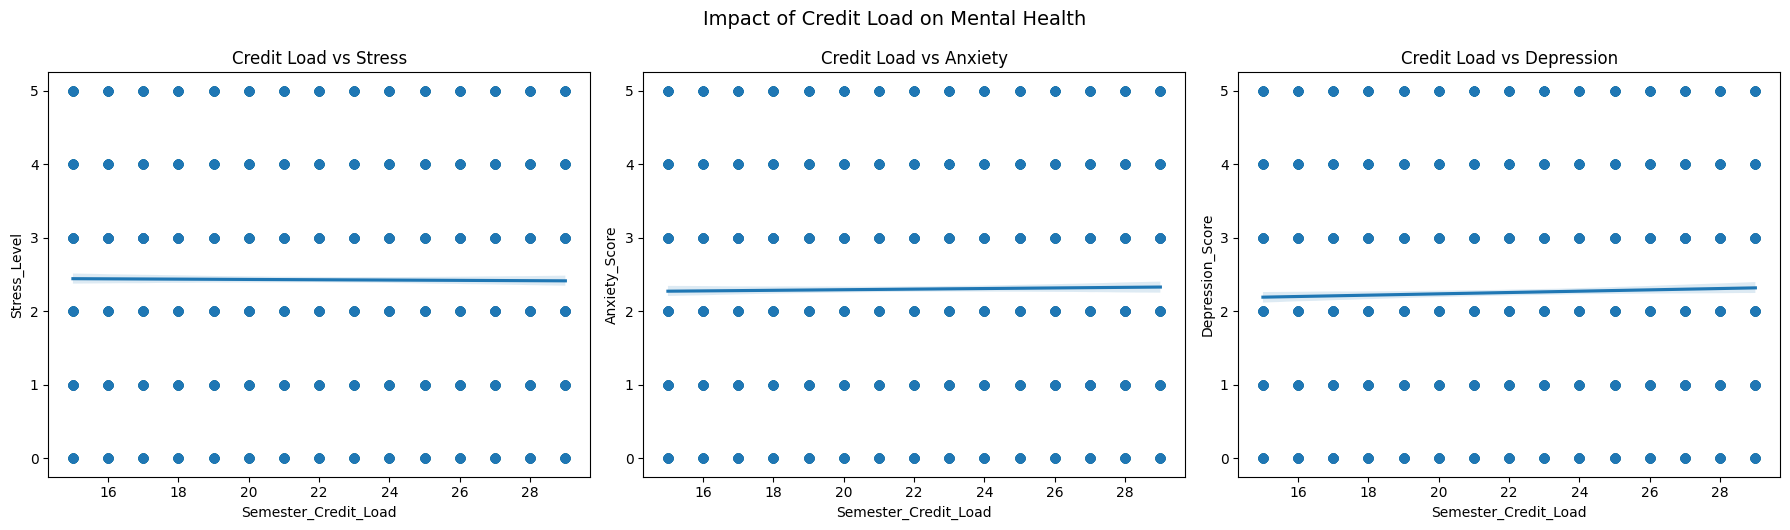

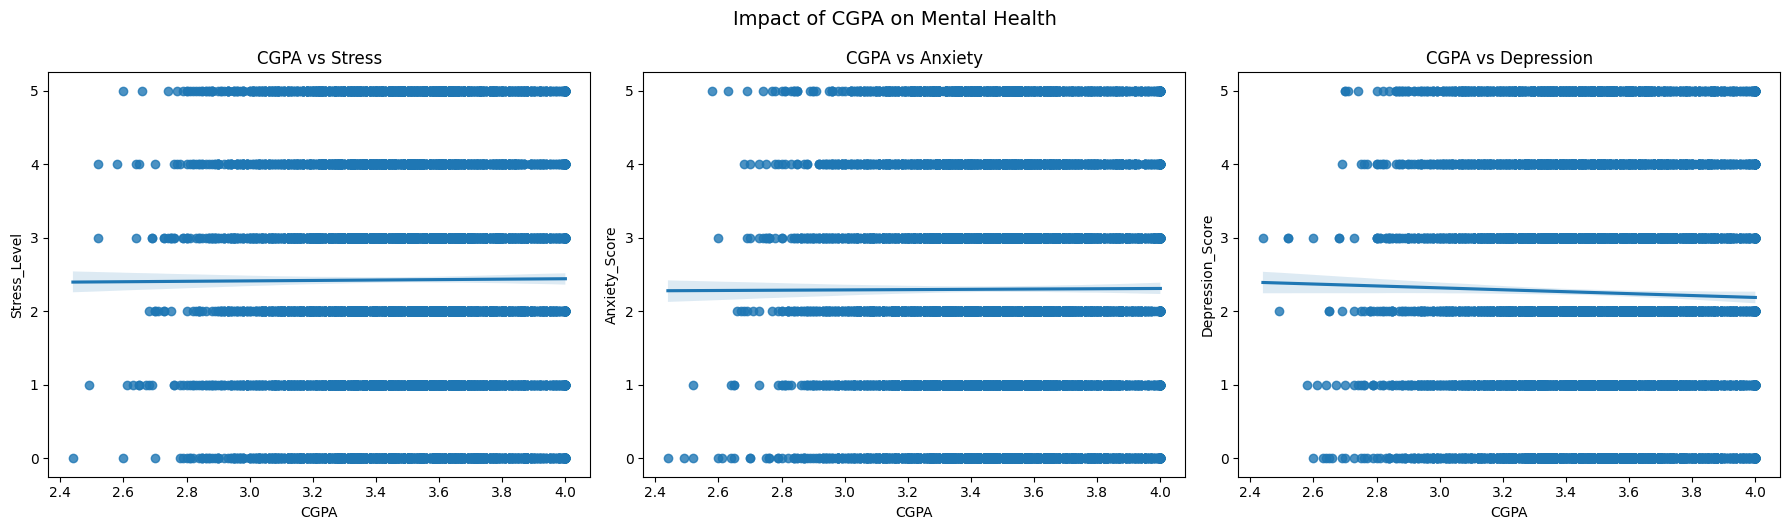

In [26]:
# Data
cols = ['CGPA', 'Semester_Credit_Load',
        'Stress_Level', 'Anxiety_Score', 'Depression_Score']

data = df[cols].dropna()

# -------------------------------
# 1. HEATMAP (separate)
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Workload vs Mental Health")
plt.show()

# -------------------------------
# 2. CREDIT LOAD SUBPLOTS
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(ax=axes[0], x='Semester_Credit_Load', y='Stress_Level',
            data=data, scatter_kws={'alpha':0.6})
axes[0].set_title("Credit Load vs Stress")

sns.regplot(ax=axes[1], x='Semester_Credit_Load', y='Anxiety_Score',
            data=data, scatter_kws={'alpha':0.6})
axes[1].set_title("Credit Load vs Anxiety")

sns.regplot(ax=axes[2], x='Semester_Credit_Load', y='Depression_Score',
            data=data, scatter_kws={'alpha':0.6})
axes[2].set_title("Credit Load vs Depression")

plt.tight_layout()
plt.suptitle("Impact of Credit Load on Mental Health", y=1.05, fontsize=14)
plt.show()

# -------------------------------
# 3. CGPA SUBPLOTS
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(ax=axes[0], x='CGPA', y='Stress_Level', data=data)
axes[0].set_title("CGPA vs Stress")

sns.regplot(ax=axes[1], x='CGPA', y='Anxiety_Score', data=data)
axes[1].set_title("CGPA vs Anxiety")

sns.regplot(ax=axes[2], x='CGPA', y='Depression_Score', data=data)
axes[2].set_title("CGPA vs Depression")

plt.tight_layout()
plt.suptitle("Impact of CGPA on Mental Health", y=1.05, fontsize=14)
plt.show()

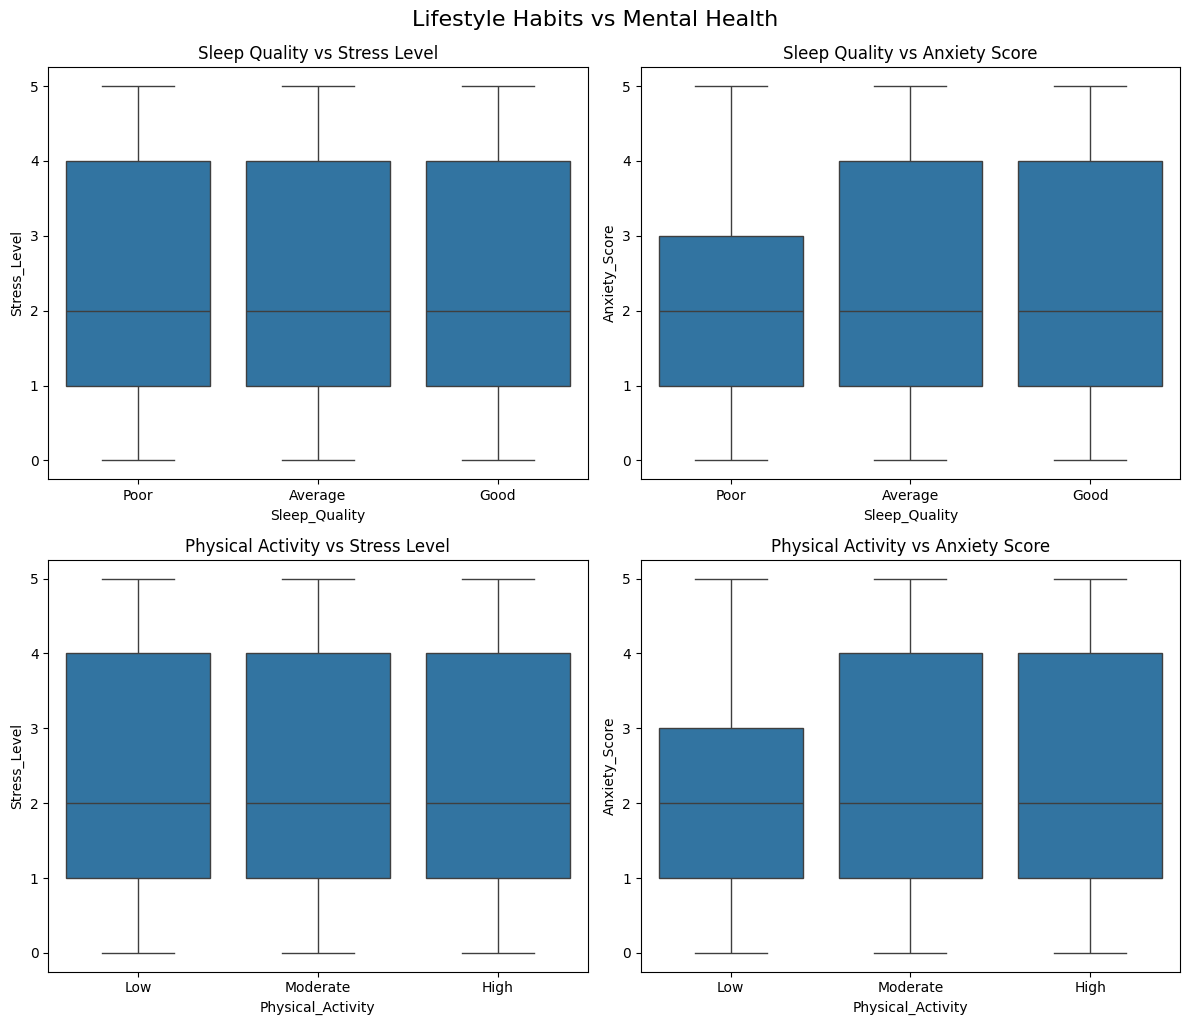

In [58]:
data = df[['Sleep_Quality', 'Physical_Activity',
           'Stress_Level', 'Anxiety_Score']].dropna()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1. Sleep Quality vs Stress
sns.boxplot(ax=axes[0,0], x='Sleep_Quality', y='Stress_Level',
            data=data, order=['Poor','Average','Good'])
axes[0,0].set_title("Sleep Quality vs Stress Level")

# 2. Sleep Quality vs Anxiety
sns.boxplot(ax=axes[0,1], x='Sleep_Quality', y='Anxiety_Score',
            data=data, order=['Poor','Average','Good'])
axes[0,1].set_title("Sleep Quality vs Anxiety Score")

# 3. Physical Activity vs Stress
sns.boxplot(ax=axes[1,0], x='Physical_Activity', y='Stress_Level',
            data=data, order=['Low','Moderate','High'])
axes[1,0].set_title("Physical Activity vs Stress Level")

# 4. Physical Activity vs Anxiety
sns.boxplot(ax=axes[1,1], x='Physical_Activity', y='Anxiety_Score',
            data=data, order=['Low','Moderate','High'])
axes[1,1].set_title("Physical Activity vs Anxiety Score")

# Layout
plt.tight_layout()
plt.suptitle("Lifestyle Habits vs Mental Health", fontsize=16, y=1.02)

plt.show()

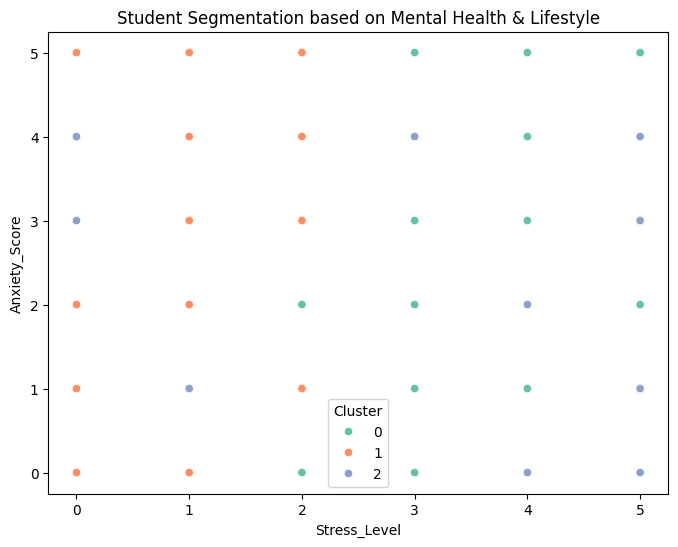

In [28]:
features = df[['Stress_Level', 'Anxiety_Score', 'Depression_Score',
               'Sleep_Quality', 'Physical_Activity']].dropna()


sleep_map = {'Poor': 0, 'Average': 1, 'Good': 2}
activity_map = {'Low': 0, 'Moderate': 1, 'High': 2}

features['Sleep_Quality'] = features['Sleep_Quality'].map(sleep_map)
features['Physical_Activity'] = features['Physical_Activity'].map(activity_map)

X = features.values

X = (X - X.mean(axis=0)) / X.std(axis=0)


k = 3
np.random.seed(42)
centroids = X[np.random.choice(len(X), k, replace=False)]

for _ in range(100):
    distances = np.linalg.norm(X[:, None] - centroids, axis=2)
    clusters = np.argmin(distances, axis=1)
    
    new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])
    
    if np.allclose(centroids, new_centroids):
        break
        
    centroids = new_centroids

features['Cluster'] = clusters


plt.figure(figsize=(8,6))
sns.scatterplot(x='Stress_Level', y='Anxiety_Score',
                hue='Cluster', data=features, palette="Set2")
plt.title("Student Segmentation based on Mental Health & Lifestyle")
plt.show()

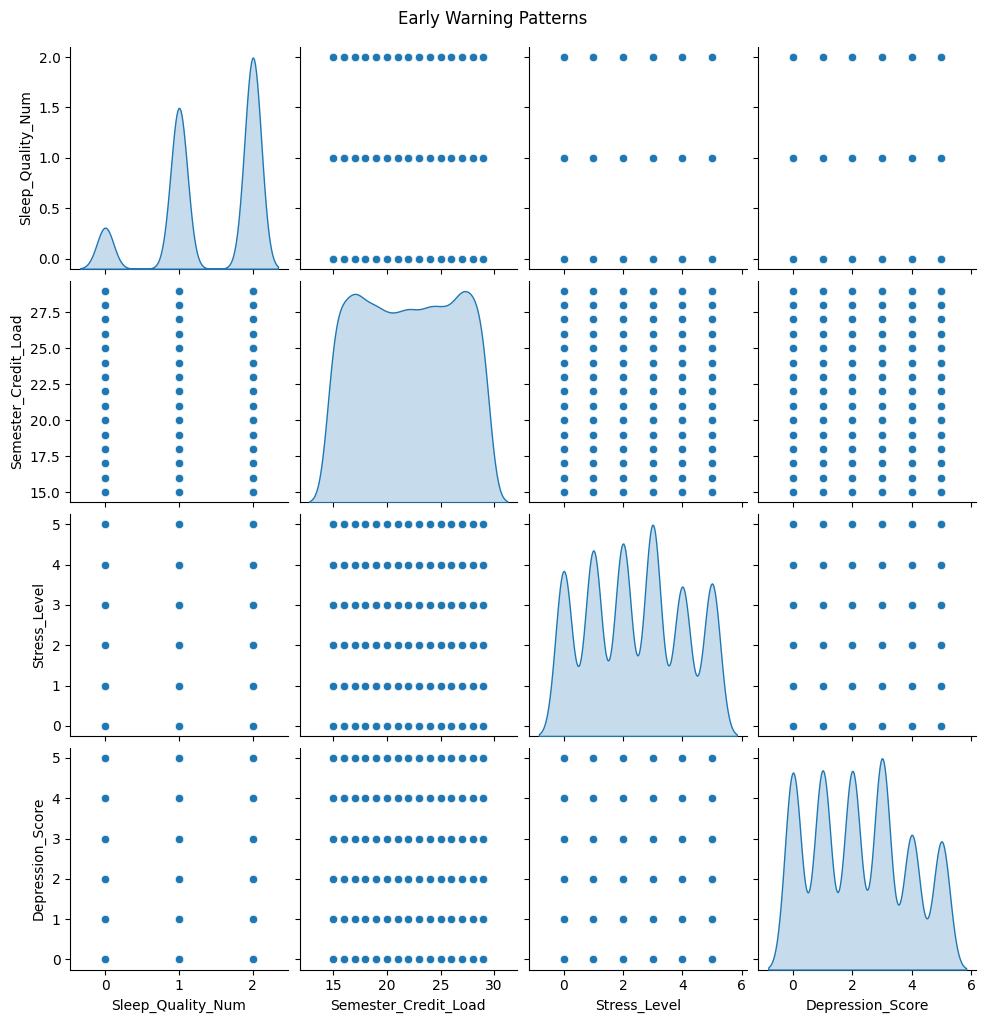

In [29]:
# Map categorical sleep quality to numeric
sleep_map = {'Poor': 0, 'Average': 1, 'Good': 2}  
# (If your data uses Poor/Average/Good, change accordingly)

df['Sleep_Quality_Num'] = df['Sleep_Quality'].map(sleep_map)

# Select columns
cols = ['Sleep_Quality_Num', 'Semester_Credit_Load',
        'Stress_Level', 'Depression_Score']
data = df[cols]

# Pairplot
sns.pairplot(data, diag_kind='kde')
plt.suptitle("Early Warning Patterns", y=1.02)
plt.show()

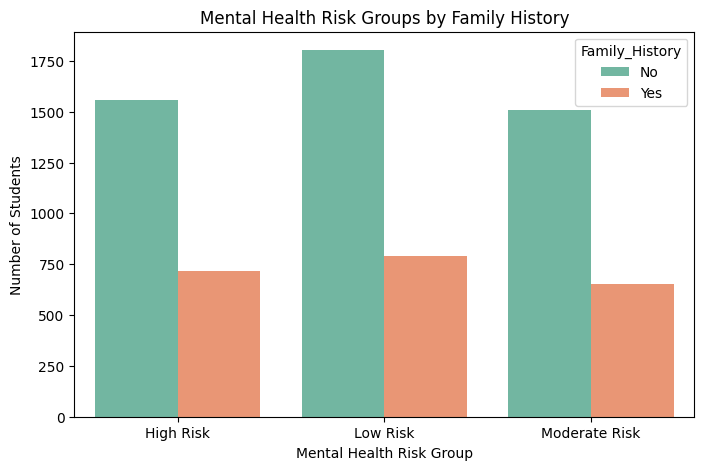

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get cluster means
cluster_means = features.groupby('Cluster')[['Stress_Level','Anxiety_Score','Depression_Score']].mean()

# Step 2: Create a risk score (average of 3 indicators)
cluster_means['Risk_Score'] = cluster_means.mean(axis=1)

# Step 3: Sort clusters by risk
sorted_clusters = cluster_means.sort_values('Risk_Score').index

# Step 4: Assign labels dynamically
labels = ['Low Risk', 'Moderate Risk', 'High Risk']
cluster_map = {cluster: labels[i] for i, cluster in enumerate(sorted_clusters)}

# Map labels
features['Cluster_Label'] = features['Cluster'].map(cluster_map)

# Add Family History
features['Family_History'] = df['Family_History']

# Clean data
data = features[['Cluster_Label', 'Family_History']].dropna()

# Step 5: Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster_Label', hue='Family_History', data=data, palette="Set2")

plt.title("Mental Health Risk Groups by Family History")
plt.xlabel("Mental Health Risk Group")
plt.ylabel("Number of Students")

plt.show()

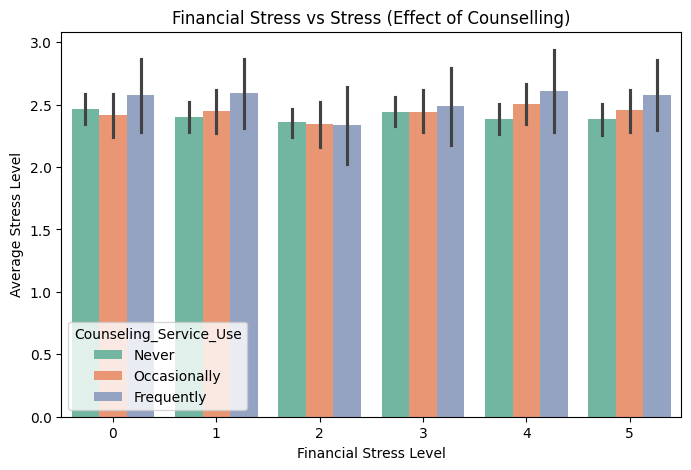

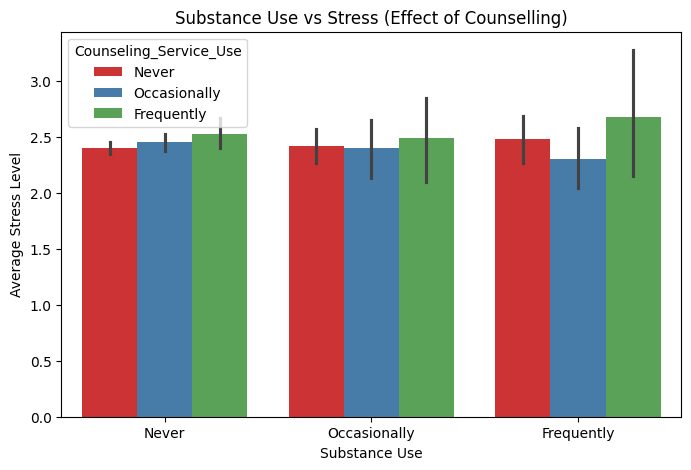

In [31]:
# Select relevant columns 
cols = ['Financial_Stress', 'Substance_Use',
        'Counseling_Service_Use', 'Stress_Level']

data = df[cols].dropna()


# Financial Stress vs Stress (with counselling)

plt.figure(figsize=(8,5))
sns.barplot(x='Financial_Stress', y='Stress_Level',
            hue='Counseling_Service_Use', data=data, palette="Set2")

plt.title("Financial Stress vs Stress (Effect of Counselling)")
plt.xlabel("Financial Stress Level")
plt.ylabel("Average Stress Level")
plt.show()

# Substance Use vs Stress (with counselling)

plt.figure(figsize=(8,5))
sns.barplot(x='Substance_Use', y='Stress_Level',
            hue='Counseling_Service_Use', data=data, palette="Set1")

plt.title("Substance Use vs Stress (Effect of Counselling)")
plt.xlabel("Substance Use")
plt.ylabel("Average Stress Level")
plt.show()

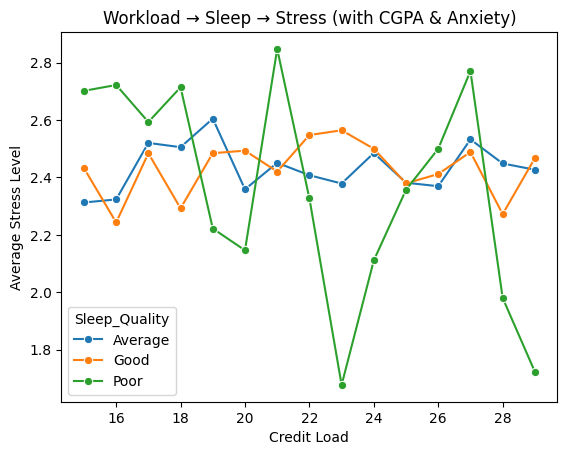

In [40]:
# Convert CGPA into categories 
df['CGPA_Category'] = pd.cut(
    df['CGPA'],
    bins=[0, 6, 8, 10],
    labels=['Low', 'Medium', 'High']
)

# Aggregate
df_q7 = df.groupby(
    ['Semester_Credit_Load','Sleep_Quality','CGPA_Category']
)[['Stress_Level','Anxiety_Score']].mean().reset_index()

plt.figure()

sns.lineplot(
    data=df_q7,
    x='Semester_Credit_Load',
    y='Stress_Level',
    hue='Sleep_Quality',
    sizes=(1,5),
    marker='o'
)

plt.title('Workload → Sleep → Stress (with CGPA & Anxiety)')
plt.xlabel('Credit Load')
plt.ylabel('Average Stress Level')

plt.show()

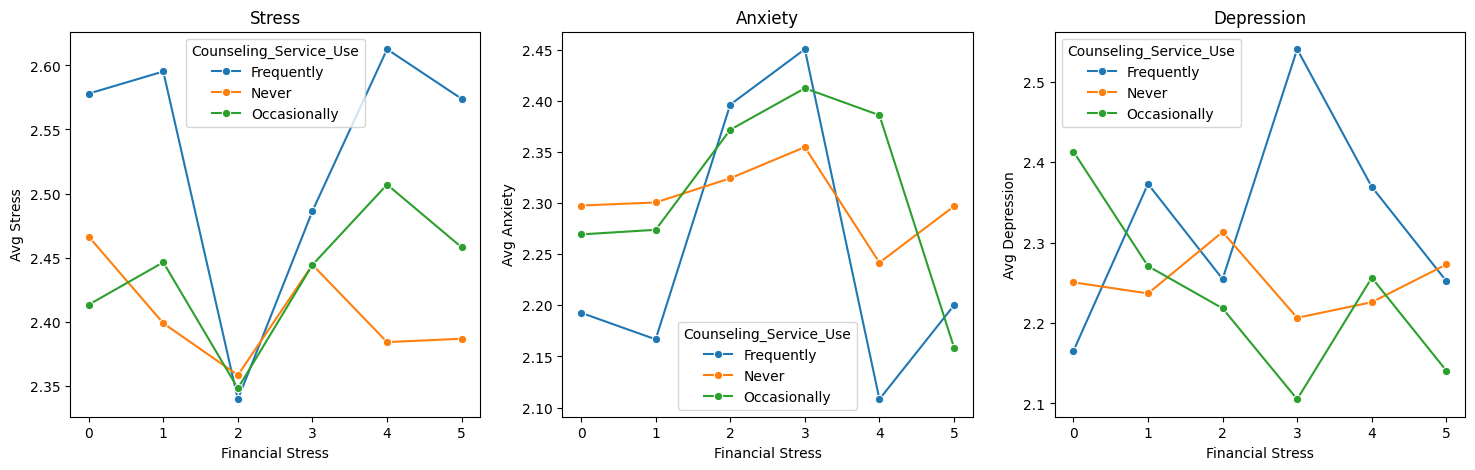

In [54]:
# Aggregate data
df_q8 = df.groupby(
    ['Financial_Stress', 'Counseling_Service_Use']
)[['Stress_Level', 'Anxiety_Score', 'Depression_Score']].mean().reset_index()

# Create subplots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Stress Plot
sns.lineplot(
    data=df_q8,
    x='Financial_Stress',
    y='Stress_Level',
    hue='Counseling_Service_Use',
    markers=True,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Stress')
axes[0].set_xlabel('Financial Stress')
axes[0].set_ylabel('Avg Stress')

# 2. Anxiety Plot
sns.lineplot(
    data=df_q8,
    x='Financial_Stress',
    y='Anxiety_Score',
    hue='Counseling_Service_Use',
    markers=True,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Anxiety')
axes[1].set_xlabel('Financial Stress')
axes[1].set_ylabel('Avg Anxiety')

# 3. Depression Plot
sns.lineplot(
    data=df_q8,
    x='Financial_Stress',
    y='Depression_Score',
    hue='Counseling_Service_Use',
    markers=True,
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Depression')
axes[2].set_xlabel('Financial Stress')
axes[2].set_ylabel('Avg Depression')


plt.show()